In [1]:
# @title Github Data Loader, GPT2 Loader

import os

try:
    import google.colab
    REPO_URL = "https://github.com/wtheisen/nd-cse-10124-lectures.git"

    REPO_NAME = "/content/nd-cse-10124-lectures"
    L_PATH = "nd-cse-10124-lectures"

    %cd /content/
    !rm -r {REPO_NAME}

    # Clone repo
    if not os.path.exists(REPO_NAME):
        !git clone {REPO_URL}

        # cd into the data folder
        %cd {L_PATH}
        !pwd

except ImportError:
    print("Unable to download repo, either:")
    print("\tA.) You're not on colab")
    print("\tB.) It has already been cloned")

!pwd

import torch
from transformers import GPT2Tokenizer, GPT2Model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")

/content
rm: cannot remove '/content/nd-cse-10124-lectures': No such file or directory
Cloning into 'nd-cse-10124-lectures'...
remote: Enumerating objects: 396, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 396 (delta 75), reused 96 (delta 45), pack-reused 267 (from 1)
Receiving objects: 100% (396/396), 34.32 MiB | 22.79 MiB/s, done.
Resolving deltas: 100% (251/251), done.
/content/nd-cse-10124-lectures
/content/nd-cse-10124-lectures
/content/nd-cse-10124-lectures
device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2Model LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [2]:
# Token embeddings (vocab_size x hidden_size)
token_embeddings = model.get_input_embeddings().weight  # same as wte.weight

# Positional embeddings (max_positions x hidden_size)
positional_embeddings = model.wpe.weight  # GPT2Model exposes wpe directly

print("Token Embedding Shape:", token_embeddings.shape)
print("Positional Embedding Shape:", positional_embeddings.shape)

text = "I like cute kitties and"
inputs = tokenizer(text, return_tensors="pt")
print('Tokens', inputs)

input_ids = inputs["input_ids"]
pos_ids = torch.arange(input_ids.size(1)).unsqueeze(0)  # (1, seq_len)

with torch.no_grad():
    tok = model.get_input_embeddings()(input_ids)   # (1, seq_len, 768)
    pos = model.wpe(pos_ids)                        # (1, seq_len, 768)
    embeddings = tok + pos                          # (1, seq_len, 768)
    embeddings = embeddings.squeeze(0)

print(embeddings.shape)

Token Embedding Shape: torch.Size([50257, 768])
Positional Embedding Shape: torch.Size([1024, 768])
Tokens {'input_ids': tensor([[   40,   588, 13779,   479,   715,   444,   290]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1]])}
torch.Size([7, 768])


In [3]:
# @title Manual Fake Embeddings

# import torch

# # Tokens for the sentence "I like cute kitties and"
# sentence = torch.tensor(
#     [
#         40, # "I"
#         1299, # " like"
#         23172, # " cute"
#         372, # " k"
#         1387, # "itt"
#         566, # "ies"
#         326, # " and"
#     ]
# )

# print(sentence)

# # Compute the token embeddings for the sentence
# torch.manual_seed(123)

# # Vocabulary size of 10, embedding dimension of 16
# embed = torch.nn.Embedding(10, 16)
# embeddings = embed(sentence).detach()

# print(embeddings.shape)

In [4]:
torch.manual_seed(123)

T, D = embeddings.shape
num_heads = 12
d_head = D // num_heads

attention_heads = {}

for head_num in range(num_heads):
    # Project from model dim -> head dim
    W_Q = torch.randn(D, d_head)
    W_K = torch.randn(D, d_head)
    W_V = torch.randn(D, d_head)

    Q = embeddings @ W_Q   # (T, d_head)
    K = embeddings @ W_K   # (T, d_head)
    V = embeddings @ W_V   # (T, d_head)

    attention_heads[head_num] = {'Q': Q, 'K': K, 'V': V}

print(Q.shape, K.shape, V.shape)

torch.Size([7, 64]) torch.Size([7, 64]) torch.Size([7, 64])


In [5]:
import math
from torch.nn import functional as F

# Compute the attention scores per head
for head_num, qkv in attention_heads.items():
    scores = (Q @ K.T) / math.sqrt(d_head)
    attn_scores = F.softmax(scores, dim=-1)   # softmax over keys

    attention_heads[head_num]['attn_scores'] = attn_scores

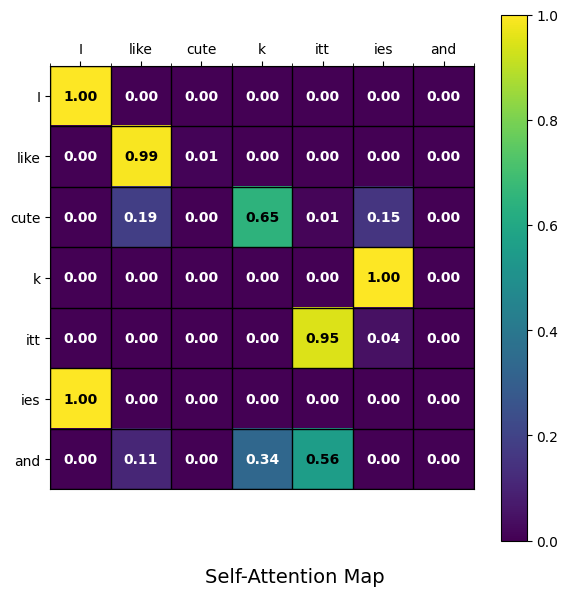

In [6]:
# @title Visualize Attention Scores

import matplotlib.pyplot as plt
import numpy as np

tokens = ["I", "like", "cute", "k", "itt", "ies", "and"]

fig, ax = plt.subplots(figsize=(6,6))

# heatmap
im = ax.imshow(attn_scores, cmap="viridis")

# ---- ticks ----
ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens)
ax.set_yticklabels(tokens)

# x labels on TOP
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

# ---- cell borders ----
ax.set_xticks(np.arange(-.5, len(tokens), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(tokens), 1), minor=True)
ax.grid(which="minor", color="black", linewidth=1)
ax.tick_params(which="minor", bottom=False, left=False)

# ---- contrast-aware annotations ----
cmap = im.get_cmap()
norm = im.norm

for i in range(attn_scores.shape[0]):
    for j in range(attn_scores.shape[1]):
        val = attn_scores[i, j].item()

        r, g, b, _ = cmap(norm(val))
        luminance = 0.2126*r + 0.7152*g + 0.0722*b

        text_color = "black" if luminance > 0.5 else "white"

        ax.text(
            j, i,
            f"{val:.2f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=10,
            fontweight="bold"
        )

# colorbar
fig.colorbar(im, ax=ax)

# title on bottom
fig.text(0.5, 0.02, "Self-Attention Map", ha="center", fontsize=14)

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

In [7]:
# Compute the context vectors per head
for head_num, qkv in attention_heads.items():
    qkv['cvs'] = context_vectors = qkv['attn_scores'] @ qkv['V']

print('Input (Token Embedding) vectors:', embeddings.shape)
print('Output (Context) vectors:', context_vectors.shape)

Input (Token Embedding) vectors: torch.Size([7, 768])
Output (Context) vectors: torch.Size([7, 64])


In [8]:
# Concatentate head outputs and project back to embedding size
head_outputs = [attention_heads[h]["cvs"] for h in range(num_heads)]
concated_vectors = torch.cat(head_outputs, dim=-1)
print("Concatenated Size:", concated_vectors.shape)

W_proj = torch.randn(768, 768)
context_vectors = concated_vectors @ W_proj.T

context_aware_embeddings = embeddings + context_vectors
print('Context Aware Embeddings:', context_aware_embeddings.shape)

Concatenated Size: torch.Size([7, 768])
Context Aware Embeddings: torch.Size([7, 768])
